In [1]:
# importing all the essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# importing all the cleaned file in python
viewing=pd.read_csv("viewing_activity_clean.csv")
ratings=pd.read_csv("ratings_feedback_clean.csv")
users=pd.read_csv("user_profile_clean.csv")
content=pd.read_csv("content_library_clean.csv")
subscription=pd.read_csv("subscription_retention_clean.csv")

In [3]:
df = viewing.merge(users, on="user_id", how="left")
df = df.merge(ratings, on='user_id', how='left')
df = df.merge(subscription, on="user_id", how="left")

In [4]:
# dropping missing values from these columns
X = df.dropna(subset=['watch_duration_minutes','completion_percentage','subscription_duration_days','churn_flag'])

In [5]:
df = df.dropna()

# Logistic Regression

In [6]:
# target column
y = df['churn_flag']

In [7]:
X = df[['watch_duration_minutes',
        'completion_percentage',
        'subscription_duration_days',
        'paused_times',
        'monthly_fee']]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 1, 1])

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

F1 Score: 0.6897618436231371
Accuracy: 0.6974166666666667
[[16458  3446]
 [ 7447  8649]]


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.83      0.75     19904
           1       0.72      0.54      0.61     16096

    accuracy                           0.70     36000
   macro avg       0.70      0.68      0.68     36000
weighted avg       0.70      0.70      0.69     36000



# Insights
## The model achieves 70% accuracy, with strong performance in identifying non-churn users (83% recall).However, it detects only 53% of actual churn users, meaning nearly half of at-risk customers are missed.

# Kmeans

In [14]:
features = ['user_id','rating','completion_percentage','subscription_duration_days']
data = df[features]

In [15]:
user_df = data.groupby('user_id').agg({
    'rating': 'mean',
    'completion_percentage': 'mean',
    'subscription_duration_days': 'first'
}).reset_index()

In [16]:
X = user_df[['rating','completion_percentage','subscription_duration_days']]

In [17]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col != "rating"]

In [18]:
numerical_cols

['watch_duration_minutes',
 'completion_percentage',
 'paused_times',
 'subscription_duration_days',
 'monthly_fee',
 'churn_flag']

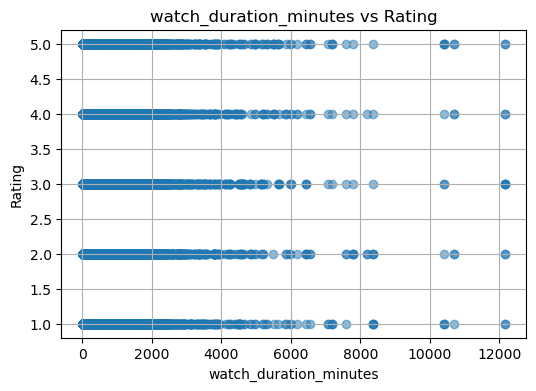

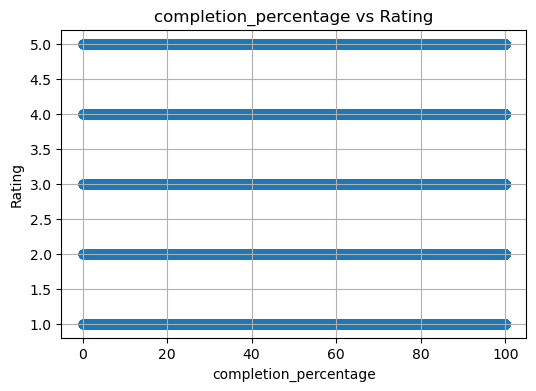

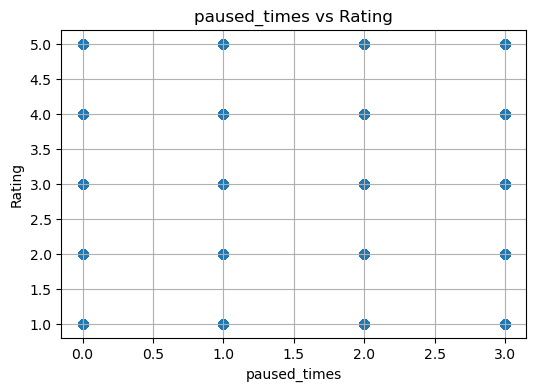

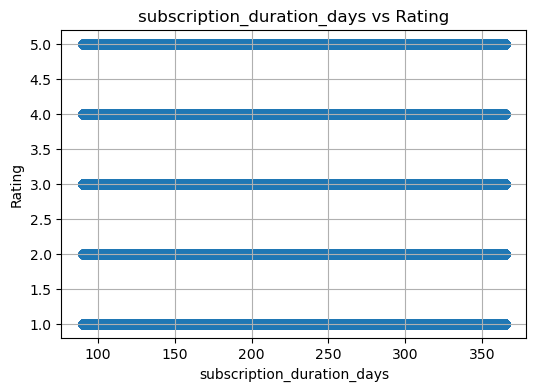

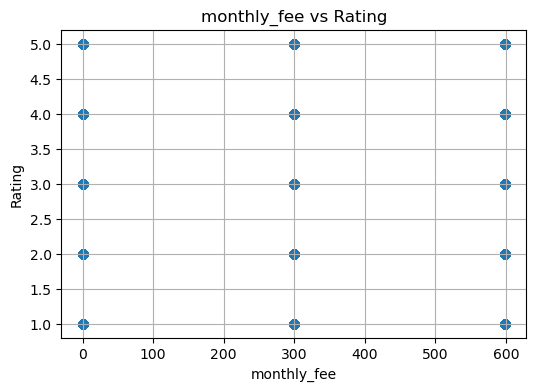

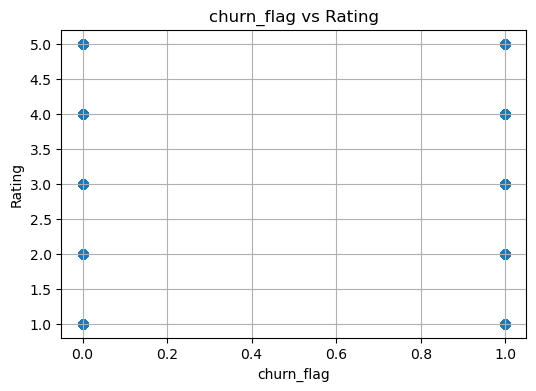

In [19]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['rating'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('Rating')
    plt.title(f'{col} vs Rating')
    plt.grid(True)
    plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [22]:
X.isnull().sum()

rating                        0
completion_percentage         0
subscription_duration_days    0
dtype: int64

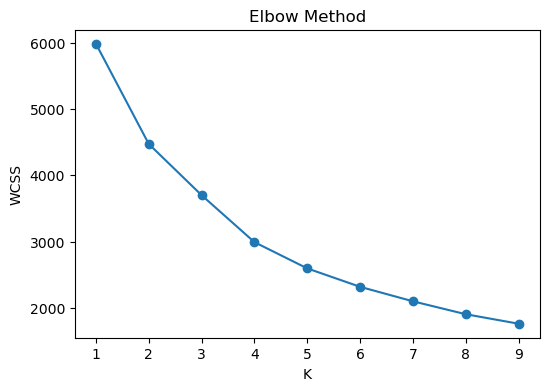

In [23]:
wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
user_df['cluster'] = kmeans.fit_predict(X_scaled)

In [25]:
cluster_names = {
    0: 'Prospective Users',
    1: 'At-Risk Users',
    2: 'High Engagers'
}
user_df['segment'] = user_df['cluster'].map(cluster_names)

In [26]:
colors = {
    0: 'blue',      # prospective Users
    1: 'red',       # At-Risk Users
    2: 'green'      # High Engagers
}

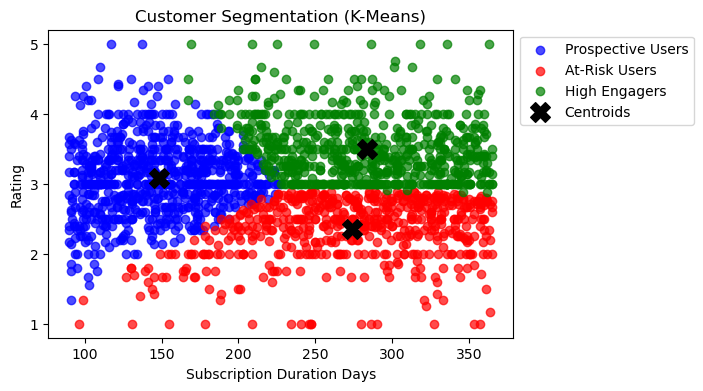

In [27]:
plt.figure(figsize=(6,4))
clusters = user_df['cluster'].unique()

# Convert centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot clusters with custom colors + names
for i in clusters:
    plt.scatter(
        user_df[user_df['cluster']==i]['subscription_duration_days'],
        user_df[user_df['cluster']==i]['rating'],
        color=colors[i],
        label=cluster_names[i],
        alpha=0.7
    )

# Plot centroids
plt.scatter(
    centroids[:,2],
    centroids[:,0],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.yticks([1,2,3,4,5])
plt.xlabel('Subscription Duration Days')
plt.ylabel('Rating')
plt.title('Customer Segmentation (K-Means)')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [28]:
labels = kmeans.fit_predict(X)

In [29]:
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5586753768377206


In [30]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

In [31]:
db_score = davies_bouldin_score(X, labels)
print("Davies-Bouldin Score:", db_score)
ch_score = calinski_harabasz_score(X, labels)
print("Calinski-Harabasz Score:", ch_score)

Davies-Bouldin Score: 0.5428148388252839
Calinski-Harabasz Score: 7258.010014857899


# INSIGHTS
## The K-Means model segments customers into meaningful groups like prospective users, high engagers, and at-risk users. It clearly identifies loyal users, but some overlap between clusters indicates that customer behavior patterns are not always sharply separated.

# Identifying why At risk users are not satisfied

In [32]:
# Filter the at risk users
risk_users = user_df[user_df['cluster'] == 1]
risk_users

,user_id,rating,completion_percentage,subscription_duration_days,cluster,segment
1,U0002,2.000000,38.666667,248,1,At-Risk Users
3,U0004,2.000000,54.000000,352,1,At-Risk Users
8,U0009,2.666667,55.933333,322,1,At-Risk Users
9,U0010,2.333333,48.733333,234,1,At-Risk Users
16,U0017,2.500000,40.800000,358,1,At-Risk Users
...,...,...,...,...,...,...
1978,U1985,2.750000,55.933333,288,1,At-Risk Users
1981,U1988,2.833333,43.800000,232,1,At-Risk Users
1982,U1989,2.857143,55.866667,246,1,At-Risk Users
1989,U1996,2.750000,52.000000,361,1,At-Risk Users


In [33]:
risk_users[[
    'rating',
    'completion_percentage',
    'subscription_duration_days'
]].mean()

rating                          2.346107
completion_percentage          52.040447
subscription_duration_days    273.880071
dtype: float64

# this tells that users are giving very low ratings which means they are dissatisfied by content quality n reccomendations,completion percentage is also half which mean users are not finishing the content which tells reduced engagement but These users have stayed on the platform for a long time but are still dissatisfied, making them high-risk churn customers. 

In [34]:
user_df.groupby('segment')[[
    'rating',
    'completion_percentage',
    'subscription_duration_days'
]].mean()

,rating,completion_percentage,subscription_duration_days
segment,,,
At-Risk Users,2.346107,52.040447,273.880071
High Engagers,3.491475,51.984087,283.982839
Prospective Users,3.079670,52.903223,148.147583


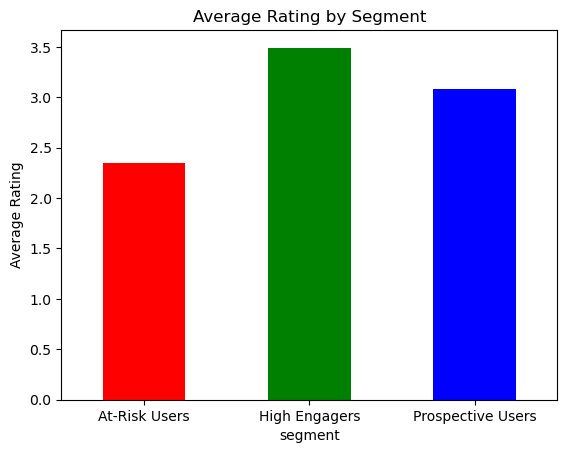

In [35]:
import matplotlib.pyplot as plt

rating_data = user_df.groupby('segment')['rating'].mean()

rating_data.plot(
    kind='bar',
    color=['red', 'green', 'blue']
)

plt.title("Average Rating by Segment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

plt.show()

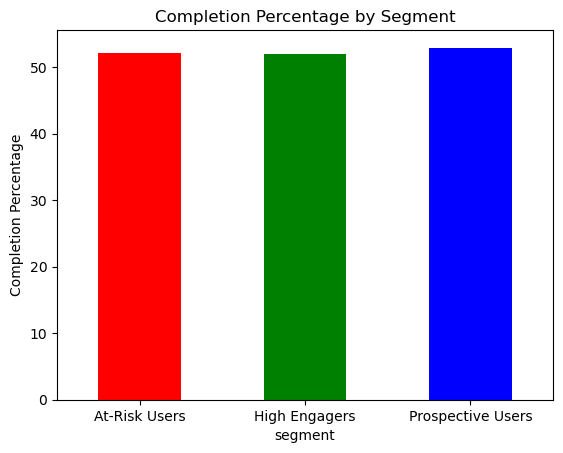

In [36]:
completion_data = user_df.groupby('segment')['completion_percentage'].mean()

completion_data.plot(
    kind='bar',
    color=['red', 'green', 'blue']
)

plt.title("Completion Percentage by Segment")
plt.ylabel("Completion Percentage")
plt.xticks(rotation=0)

plt.show()

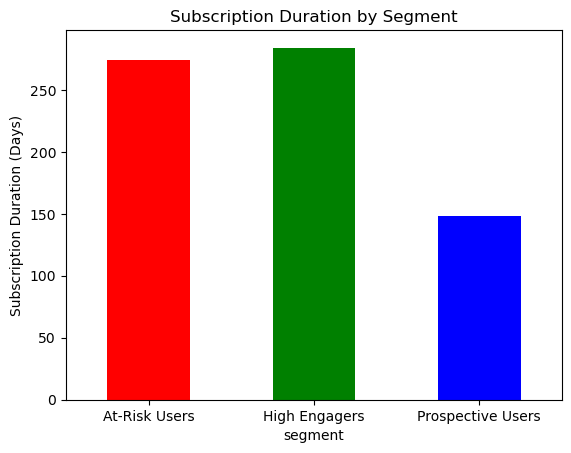

In [37]:
duration_data = user_df.groupby('segment')['subscription_duration_days'].mean()

duration_data.plot(
    kind='bar',
    color=['red', 'green', 'blue']
)

plt.title("Subscription Duration by Segment")
plt.ylabel("Subscription Duration (Days)")
plt.xticks(rotation=0)

plt.show()

# KNN Classifier

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import f1_score

In [39]:
le = LabelEncoder()
y = le.fit_transform(df['subscription_type_y'])

In [40]:
X = df[['watch_duration_minutes','completion_percentage','paused_times','rating','subscription_duration_days']].copy()

In [41]:
df['rewatched_flag'] = df['rewatched_flag'].map({'Y': 1, 'N': 0})

In [42]:
X = X.fillna(X.mean())

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
k_values = []
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    k_values.append(k)
    accuracies.append(acc)

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_acc)

Best K: 1
Best Accuracy: 0.75425


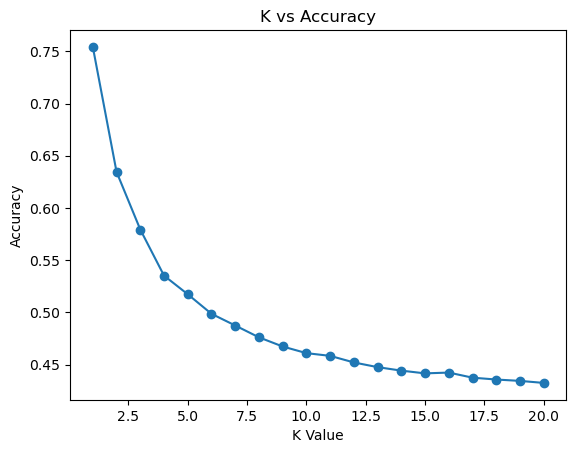

In [46]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [47]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [48]:
y_pred = model.predict(X_test)

In [49]:
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Final Accuracy: 0.75425
Confusion Matrix:
 [[8853 1426 1456]
 [1500 9047 1548]
 [1381 1536 9253]]
F1 Score: 0.7542416660379395


# INSIGHTS
## The KNN classifier achieves an overall accuracy of 75.4%, showing good performance in predicting user subscription types. It performs relatively well across all three classes, with balanced predictions and no extreme bias toward any single category.

# KNN REGRESSOR

In [50]:
X = content[[
    'duration_numeric','engagement_proxy',
    'genre_count',
    'content_age_years'
]].copy()

y = content['popularity_score']

In [51]:
y

0         9.8
1         6.0
2         6.0
3         6.0
4         6.0
         ... 
17792    12.8
17793    11.2
17794    11.0
17795    10.6
17796    11.0
Name: popularity_score, Length: 17797, dtype: float64

In [52]:
X = X.fillna(X.mean())
X

,duration_numeric,engagement_proxy,genre_count,content_age_years
0,90.0,882.0,1,5
1,2.0,7200.0,3,4
2,1.0,3600.0,3,4
3,1.0,3600.0,2,4
4,2.0,7200.0,3,4
...,...,...,...,...
17792,156.0,1996.8,2,2
17793,1.0,6720.0,2,3
17794,120.0,1320.0,2,2
17795,3.0,19080.0,2,3


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = []
mse_scores = []

best_k = 1
best_mse = float('inf')

for k in range(1, 10):

    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    k_values.append(k)
    mse_scores.append(mse)

    print(f"K = {k}, MSE = {mse}")

    # Best K = minimum MSE
    if mse < best_mse:
        best_mse = mse
        best_k = k

print("\nBest K:", best_k)
print("Best MSE:", best_mse)

K = 1, MSE = 1.4039662921348313
K = 2, MSE = 1.3590842696629213
K = 3, MSE = 1.4389662921348316
K = 4, MSE = 1.4905723314606742
K = 5, MSE = 1.5593658426966293
K = 6, MSE = 1.6427278401997503
K = 7, MSE = 1.791636092639303
K = 8, MSE = 1.8833395365168537
K = 9, MSE = 1.9974323761964212

Best K: 2
Best MSE: 1.3590842696629213


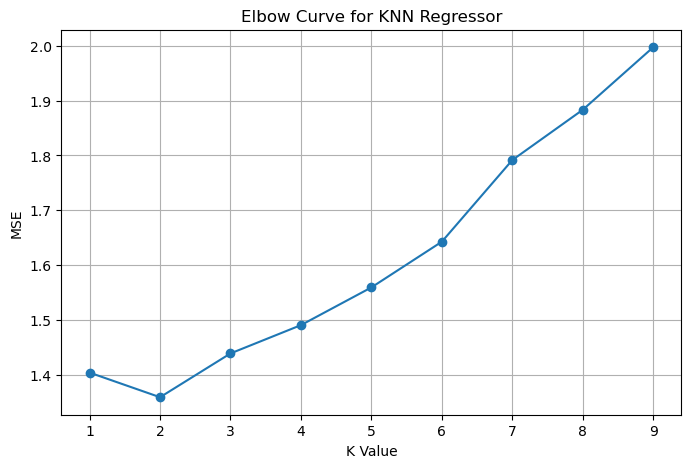

In [56]:
plt.figure(figsize=(8,5))

plt.plot(k_values, mse_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("MSE")

plt.title("Elbow Curve for KNN Regressor")

plt.grid(True)

plt.show()

In [57]:
model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import mean_squared_error,r2_score

print("Final R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Final R2 Score: 0.9076404210308382
MSE: 1.3590842696629213


In [60]:
content[['numeric_rating', 'popularity_score']].corr()

,numeric_rating,popularity_score
numeric_rating,1.000000,0.660601
popularity_score,0.660601,1.000000
